# Install dependencies

In [ ]:
# !pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/

In [ ]:
!pip install -q --no-warn-script-location \
    paddlepaddle-gpu==3.3.0 \
    -i https://www.paddlepaddle.org.cn/packages/stable/cu130/

     ━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━ 0.7/1.4 GB 16.4 MB/s eta 0:00:42

In [ ]:

!pip install -q --no-warn-script-location \
    paddleocr \
    opencv-python-headless \
    tqdm \
    "langchain>=0.3,<0.4" \
    "langchain-core>=0.3,<0.4" \
    "langchain-text-splitters>=0.3,<0.4" \
    rapidfuzz \
    vietocr

# Import

In [2]:

import cv2
import os
import json
import time
from pathlib import Path
from tqdm.notebook import tqdm
from paddleocr import PaddleOCR


import matplotlib.pyplot as plt
import numpy as np


import re
import unicodedata
from math import floor
from typing import List, Dict, Any
from transformers import AutoTokenizer
from PIL import Image
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg
import pandas as pd

# Init PaddleOCR

In [4]:

# ─────────────────────────────────────────────
# Khởi tạo PaddleOCR (tiếng Việt)
# ─────────────────────────────────────────────
def init_ocr(use_gpu: bool = True) -> PaddleOCR:
    ocr = PaddleOCR(
        use_textline_orientation=True,
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        lang="latin",
        text_detection_model_name="PP-OCRv5_server_det",
        text_recognition_model_name="PP-OCRv5_server_rec",
        rec_batch_num=6,
    )
    print("✅ PaddleOCR sẵn sàng!\n")
    return ocr


def init_vietocr(use_gpu: bool = True) -> Predictor:
    config = Cfg.load_config_from_name('vgg_transformer')
    config['device'] = 'cuda:0' if use_gpu else 'cpu'
    config['predictor']['beamsearch'] = False  # False = nhanh hơn, True = chính xác hơn
    viet_ocr = Predictor(config)
    print("✅ VietOCR (recognizer) sẵn sàng!\n")
    return viet_ocr

In [5]:
# ─────────────────────────────────────────────
# Helper: Crop vùng text từ polygon bounding box
# ─────────────────────────────────────────────

def crop_text_region(frame_bgr: np.ndarray, poly_points: list) -> "Image.Image | None":
    """
    Crop vùng text từ polygon bounding box của PaddleOCR.

    Args:
        frame_bgr  : Frame gốc dạng numpy BGR (từ OpenCV)
        poly_points: List các điểm polygon [[x1,y1],[x2,y2],...]

    Returns:
        PIL.Image (RGB) của vùng text đã crop, hoặc None nếu crop lỗi
    """
    try:
        pts = np.array(poly_points, dtype=np.int32)

        # Lấy bounding rect của polygon
        x, y, w, h = cv2.boundingRect(pts)

        # Clamp tọa độ trong frame
        H, W = frame_bgr.shape[:2]
        x  = max(0, x)
        y  = max(0, y)
        x2 = min(W, x + w)
        y2 = min(H, y + h)

        # Bỏ qua region quá nhỏ (noise)
        if (x2 - x) < 5 or (y2 - y) < 5:
            return None

        # Crop và convert BGR → RGB → PIL
        cropped_bgr = frame_bgr[y:y2, x:x2]
        cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(cropped_rgb)

        return pil_img

    except Exception:
        return None

# Extract frames

In [6]:
def extract_fixed_frames(
    video_path: str,
    num_frames: int = 5
) -> list[dict]:

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise FileNotFoundError(
            f"Không mở được video: {video_path}"
        )

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for idx in indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            idx
        )

        ret, frame = cap.read()

        if not ret:
            continue

        timestamp = idx / video_fps

        frames.append({
            "frame_idx": idx,
            "timestamp": round(timestamp, 3),
            "frame": frame
        })

    cap.release()

    print(
        f"✅ Đã trích xuất "
        f"{len(frames)} frames cố định"
    )

    return frames

# OCR Frames

In [7]:
def ocr_frames(
    ocr: "PaddleOCR",
    viet_ocr: "Predictor",
    frames: list[dict],
    conf_thresh: float = 0.6,
    viet_conf_thresh: float = 0.5,
) -> list[dict]:
    """
    Hybrid OCR pipeline:
      Stage 1 — PaddleOCR detect vùng text → bounding boxes (rec_polys)
      Stage 2 — Crop từng region → VietOCR nhận diện text tiếng Việt

    Args:
        ocr             : PaddleOCR instance (dùng để detect)
        viet_ocr        : VietOCR Predictor instance (dùng để recognize)
        frames          : List frame dict từ extract_fixed_frames()
        conf_thresh     : Ngưỡng confidence detection của PaddleOCR
        viet_conf_thresh: Ngưỡng confidence recognition của VietOCR

    Returns:
        List dict kết quả — format giống cũ, tương thích với deduplicate, merge_chunk, ...
    """
    results = []

    for item in tqdm(frames, desc="🔍 Hybrid OCR đang xử lý", unit="frame"):
        frame     = item["frame"]
        timestamp = item["timestamp"]
        frame_idx = item["frame_idx"]

        # ── Stage 1: PaddleOCR Detection ──────────────────────────────
        try:
            ocr_result_list = ocr.predict(frame)
        except Exception as e:
            print(f"\n⚠️  Frame {frame_idx} ({timestamp}s) PaddleOCR lỗi: {e}")
            continue

        if not ocr_result_list:
            continue

        res = ocr_result_list[0]

        # Lấy detection scores và polygons
        # ⚠️ Bỏ qua rec_texts của PaddleOCR — sẽ dùng VietOCR thay thế
        rec_scores = res.get("rec_scores", [])
        rec_polys  = res.get("rec_polys",  [])

        if not rec_polys:
            continue

        # ── Stage 2: VietOCR Recognition ──────────────────────────────
        texts = []

        for score, poly in zip(rec_scores, rec_polys):
            det_conf = float(score)

            # Lọc theo detection confidence của PaddleOCR
            if det_conf < conf_thresh:
                continue

            # Convert polygon → tọa độ int
            try:
                box_points = [[int(p[0]), int(p[1])] for p in poly]
            except Exception:
                continue

            # Crop vùng text ra PIL Image
            pil_crop = crop_text_region(frame, box_points)
            if pil_crop is None:
                continue

            # VietOCR nhận diện text tiếng Việt
            try:
                vi_text, vi_conf = viet_ocr.predict(pil_crop, return_prob=True)
            except Exception as e:
                continue

            vi_text = str(vi_text).strip()

            # Lọc kết quả rỗng hoặc confidence quá thấp
            if not vi_text or float(vi_conf) < viet_conf_thresh:
                continue

            texts.append({
                "text":     vi_text,
                "confidence": round(float(vi_conf), 4),
                "det_conf": round(det_conf, 4),  # giữ lại để debug
                "box":      box_points,
            })

        if texts:
            results.append({
                "frame_idx": frame_idx,
                "timestamp": timestamp,
                "texts":     texts,
            })

    return results

# Helper function

## Filter watermark

In [8]:
import re

# ─── Định nghĩa patterns ───────────────────────────────────────
TIKTOK_UI_PATTERNS = [
    # TikTok watermark
    r'(?i)tik\s*tok',              # TikTok, Tik Tok, tiktok, JittikTok
    r'(?i)j[a-z]*tik\s*tok',      # JTiktok, JittikTok
    
    # Username/handle pattern: chuỗi chữ+số không dấu, không khoảng trắng, 5–30 ký tự
    # Ví dụ: chungkien37, Ochungkien37, user_name123
    r'^[A-Za-z0-9@_\.]{5,30}$',
    
    # Số đơn lẻ (like count, follow count)
    r'^\d{1,7}[KMB]?$',
    
    # Music/caption UI ký tự đặc biệt
    r'^[♪♫🎵🎶❤👍💬🔗]+$',
]

# ─── Danh sách đen cứng ────────────────────────────────────────
TIKTOK_UI_KEYWORDS = {
    'tiktok', 'follow', 'following', 'followers',
    'like', 'share', 'comment', 'duet',
    # Thêm username cụ thể nếu biết trước (optional)
}

def is_ui_text(text: str) -> bool:
    """
    Kiểm tra text có phải là UI element của TikTok không.
    
    Returns:
        True nếu là UI text → nên bỏ qua
    """
    text_stripped = text.strip()
    
    # 1. Quá ngắn (< 2 ký tự) → likely noise
    if len(text_stripped) < 2:
        return True
    
    # 2. Khớp với keyword đen
    if text_stripped.lower() in TIKTOK_UI_KEYWORDS:
        return True
    
    # 3. Khớp với regex patterns
    for pattern in TIKTOK_UI_PATTERNS:
        if re.match(pattern, text_stripped):
            return True
    
    # 4. Tỷ lệ chữ số cao (> 70%) → likely counter/ID
    digit_ratio = sum(c.isdigit() for c in text_stripped) / len(text_stripped)
    if digit_ratio > 0.7:
        return True
    
    # 5. Không có ký tự tiếng Việt VÀ ngắn → likely UI/English label
    has_vietnamese = bool(re.search(r'[àáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]', text_stripped, re.IGNORECASE))
    if not has_vietnamese and len(text_stripped) < 20:
        return True
    
    return False

# ─── Tích hợp vào post-processing sau ocr_frames() ─────────────
def filter_ui_texts(results: list[dict]) -> list[dict]:
    """Lọc UI text khỏi kết quả OCR."""
    filtered = []
    for item in results:
        clean_texts = [t for t in item["texts"] if not is_ui_text(t["text"])]
        if clean_texts:
            filtered.append({**item, "texts": clean_texts})
    return filtered

# Cách dùng (thêm vào STEP 3.5 trong Cell Main):
# results = ocr_frames(ocr, viet_ocr, frames, ...)
# results = filter_ui_texts(results)   # ← THÊM DÒNG NÀY

## Deduplicate

In [10]:
# ─────────────────────────────────────────────
# Loại bỏ frame trùng lặp (dedup)
# ─────────────────────────────────────────────
def deduplicate(results: list[dict], window: float = 1.0) -> list[dict]:
    """
    Gộp các dòng text giống nhau xuất hiện liên tiếp trong window giây.
    Giữ lại lần xuất hiện đầu tiên.
    """
    seen: dict[str, float] = {}   # text -> last_seen timestamp
    deduped = []

    for item in results:
        ts      = item["timestamp"]
        unique  = []
        for t in item["texts"]:
            key = t["text"].lower().strip()
            if key not in seen or (ts - seen[key]) > window:
                seen[key] = ts
                unique.append(t)
        if unique:
            deduped.append({**item, "texts": unique})

    return deduped


## Temporal Aggregation

In [11]:
from rapidfuzz import fuzz

def temporal_aggregate(
    results,
    similarity_threshold=75
):
    chunks = []

    current_chunk = []

    previous_text = ""

    for item in results:

        current_text = " ".join(
            t["text"] for t in item["texts"]
        )

        if not current_chunk:
            current_chunk.append(item)

        else:
            sim = fuzz.token_set_ratio(
                previous_text,
                current_text
            )

            if sim >= similarity_threshold:
                current_chunk.append(item)
            else:
                chunks.append(current_chunk)
                current_chunk = [item]

        previous_text = current_text

    if current_chunk:
        chunks.append(current_chunk)

    return chunks

## Merge text

In [12]:
from rapidfuzz import fuzz

def merge_chunk(chunk, similarity_threshold=85):
    groups = []

    for frame in chunk:
        for text_obj in frame["texts"]:

            text = text_obj["text"].strip()
            conf = text_obj["confidence"]

            matched = False

            for group in groups:

                representative = group[0]["text"]

                sim = fuzz.ratio(
                    text.lower(),
                    representative.lower()
                )

                if sim >= similarity_threshold:
                    group.append({
                        "text": text,
                        "confidence": conf
                    })
                    matched = True
                    break

            if not matched:
                groups.append([
                    {
                        "text": text,
                        "confidence": conf
                    }
                ])

    final_lines = []

    for group in groups:

        best = max(
            group,
            key=lambda x: x["confidence"]
        )

        final_lines.append(best["text"])

    return "\n".join(final_lines)

## Save result

In [13]:
# ─────────────────────────────────────────────
# Lưu kết quả
# ─────────────────────────────────────────────
def save_results(results: list[dict], output_dir: str, video_name: str) -> dict[str, str]:
    """Lưu kết quả ra JSON và TXT."""
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    stem = Path(video_name).stem

    # --- JSON (đầy đủ, có box + confidence) ---
    json_path = out / f"{stem}_ocr.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    # --- TXT (dễ đọc) ---
    txt_path = out / f"{stem}_ocr.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"OCR Results — {video_name}\n")
        f.write("=" * 60 + "\n\n")
        for item in results:
            ts   = item["timestamp"]
            mm   = int(ts // 60)
            ss   = ts % 60
            f.write(f"[{mm:02d}:{ss:05.2f}]\n")
            for t in item["texts"]:
                f.write(f"  {t['text']}  (conf: {t['confidence']:.2f})\n")
            f.write("\n")

    return {"json": str(json_path), "txt": str(txt_path)}

## Visualization

In [14]:
def visualize_frame_with_ocr(ocr, viet_ocr, frame_item, conf_thresh: float = 0.6):
    """
    Vẽ bounding box + text OCR lên một frame.
    frame_item là 1 phần tử trong list `frames` (dict chứa 'frame', 'frame_idx', 'timestamp').
    """
    frame = frame_item["frame"].copy()
    ts    = frame_item["timestamp"]
    idx   = frame_item["frame_idx"]

    # Gọi OCR cho frame này
    ocr_result_list = ocr.predict(frame)
    if not ocr_result_list:
        print("Không có kết quả OCR cho frame", idx)
        return

    res = ocr_result_list[0]

    # Chỉ lấy detection scores + polygons (bỏ rec_texts của PaddleOCR)
    rec_scores = res.get("rec_scores", [])
    rec_polys  = res.get("rec_polys",  [])

    # Vẽ từng box + text (dùng VietOCR để nhận diện)
    for score, poly in zip(rec_scores, rec_polys):
        if score < conf_thresh:
            continue

        pts = np.array(poly, dtype=np.int32)
        box_points = [[int(p[0]), int(p[1])] for p in poly]

        # Crop và nhận diện bằng VietOCR
        pil_crop = crop_text_region(frame, box_points)
        if pil_crop is None:
            continue

        try:
            vi_text, vi_conf = viet_ocr.predict(pil_crop, return_prob=True)
            vi_text = str(vi_text).strip()
        except Exception:
            vi_text, vi_conf = "???", 0.0

        # Vẽ polygon
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

        # Vẽ text ngay góc trên của box
        # Lưu ý: cv2.putText không render dấu tiếng Việt — chỉ dùng để debug layout
        x, y = pts[0]
        cv2.putText(
            frame,
            f"{vi_text} ({vi_conf:.2f})",
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    # Hiển thị bằng matplotlib (chuyển BGR -> RGB)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"Frame {idx} @ {ts:.2f}s")
    plt.show()


## Print summary

In [15]:
# ─────────────────────────────────────────────
# In tóm tắt ra console
# ─────────────────────────────────────────────
def print_summary(results: list[dict]) -> None:
    if not results:
        print("\nKhông tìm thấy văn bản nào thỏa mãn điều kiện confidence.")
        return

    all_texts = [t["text"] for item in results for t in item["texts"]]
    avg_conf  = (
        sum(t["confidence"] for item in results for t in item["texts"]) / max(len(all_texts), 1)
    )

    print("\n" + "=" * 60)
    print("📊 KẾT QUẢ OCR")
    print("=" * 60)
    print(f"  Frames có text    : {len(results)}")
    print(f"  Tổng dòng text    : {len(all_texts)}")
    print(f"  Confidence trung bình: {avg_conf:.2%}")
    print("=" * 60)

    # In 10 kết quả đầu tiên
    print("\n🔤 Mẫu kết quả (10 frames đầu):\n")
    for item in results[:10]:
        ts = item["timestamp"]
        mm, ss = int(ts // 60), ts % 60
        print(f"  [{mm:02d}:{ss:05.2f}]")
        for t in item["texts"]:
            bar = "█" * int(t["confidence"] * 10)
            print(f"    {t['text']:<40} {bar} {t['confidence']:.0%}")
        print()

# Main

In [ ]:

# def main():
#     # --- CẤU HÌNH THAY THẾ CHO ARGPARSE ---
#     class Config:
#         video = "/kaggle/input/datasets/kietkolat/hf-dataset-somet/HF-DATASET-SOMET/videos/19b78ed3-7572141331120688402.mp4"  # 🔴 THAY ĐỔI ĐƯỜNG DẪN VIDEO TẠI ĐÂY
#         fps = 2.0
#         conf = 0.6
#         output = "/kaggle/working/ocr_output"  # Thư mục working của Kaggle để có thể tải file về
#         no_gpu = False # Đặt thành True nếu bạn không bật P100/T4 trên Kaggle
#         no_dedup = False
#         dedup_window = 1.0

#     args = Config()
    
#     # Kiểm tra file video có tồn tại không
#     if not os.path.exists(args.video):
#         print(f"❌ LỖI: Không tìm thấy file tại '{args.video}'")
#         print("Vui lòng tải video lên Kaggle Input và thay đổi biến 'args.video' cho đúng.")
#         return

#     t0 = time.time()

#     # 1. Khởi tạo OCR
#     ocr = init_ocr(use_gpu=not args.no_gpu)

#     # 2. Trích xuất frames
#     frames = extract_frames(args.video, fps_sample=args.fps)

#     # 3. Nhận diện text
#     print(f"🚀 Bắt đầu OCR {len(frames)} frames (conf ≥ {args.conf})...\n")
#     results = ocr_frames(ocr, frames, conf_thresh=args.conf)

#     # 4. Dedup (tùy chọn)
#     if not args.no_dedup:
#         before = sum(len(r["texts"]) for r in results)
#         results = deduplicate(results, window=args.dedup_window)
#         after  = sum(len(r["texts"]) for r in results)
#         print(f"\n🧹 Dedup: {before} → {after} dòng text (bỏ {before - after} trùng lặp)")

#     # 5. Tóm tắt
#     print_summary(results)
  
#     # # 6. Lưu kết quả
#     # paths = save_results(results, args.output, args.video)
#     # elapsed = time.time() - t0

#     # # Ví dụ: vẽ frame đầu tiên trong `frames`
#     # visualize_frame_with_ocr(ocr, frames[0], conf_thresh=0.6)
    
#     # # Hoặc vẽ một frame giữa video
#     # visualize_frame_with_ocr(ocr, frames[10], conf_thresh=0.6)

        

#     print(f"\n💾 Đã lưu kết quả:")
#     print(f"   JSON → {paths['json']}")
#     print(f"   TXT  → {paths['txt']}")
#     print(f"\n⏱️  Tổng thời gian: {elapsed:.1f}s")


# # Gọi hàm main để chạy
# main()

/tmp/ipykernel_164/4235277439.py:5: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
/tmp/ipykernel_164/4235277439.py:5: DeprecationWarning: The parameter `rec_batch_num` has been deprecated and will be removed in the future. Please use `text_recognition_batch_size` instead.
  ocr = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


STEP 0 - INIT OCR


Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


✅ PaddleOCR sẵn sàng!

Model weight /tmp/vgg_transformer.pth exsits. Ignore download!
✅ VietOCR (recognizer) sẵn sàng!


STEP 1 - EXTRACT FRAMES
✅ Đã trích xuất 5 frames cố định
Extracted 5 frames

STEP 2 - VISUALIZE SAMPLE FRAMES


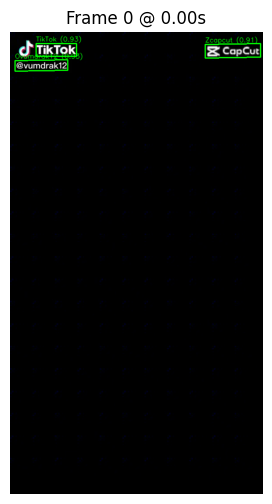

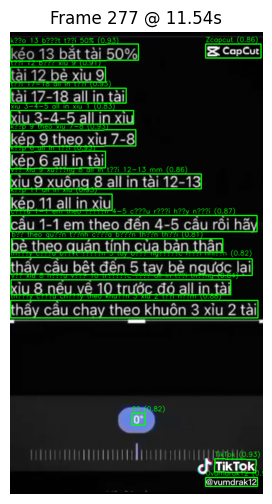

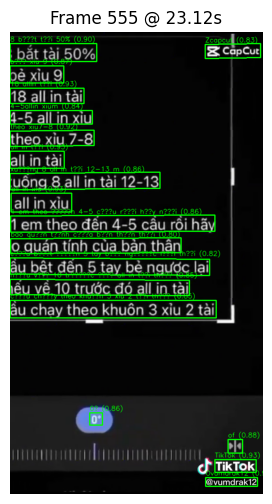

🔍 Hybrid OCR đang xử lý:   0%|          | 0/5 [00:00<?, ?frame/s]


STEP 3 - OCR - BEFORE FILTER

[0.00s]
  TikTok                                            93.35%
  Zcapcut                                           90.68%
  Ovumdrak12                                        92.51%

[5.75s]
  kéo 13 bắt tài 50%                                93.38%
  Zcapcut                                           82.33%
  tài 12 bè xiu 9                                   91.12%
  tài 17-18 all in tài                              92.70%
  xiu 3-4-5 all in xiu                              92.76%
  kép 9 theo xiu 7-8                                92.48%
  kép 6 all in tài                                  93.07%
  xiu 9 xuống 8 all in tài 12-13                    90.16%
  kép 11 all in xiu                                 93.28%
  cầu 1-1 em theo đến 4-5 cầu rồi học               89.37%
  bẻ theo quán tính của bản thân                    90.92%
  và thấy cầu bệt đến 5 tay bẻ ngược la thời        81.78%
  xiu 8 nếu về 10 trước đó all in tài               92.31%
  thấy c

In [19]:
# ==========================================================
# TEST PIPELINE TRÊN 1 VIDEO
# ==========================================================

video_path = "/kaggle/input/datasets/kietkolat/hf-dataset-somet/HF-DATASET-SOMET/videos/0b03ea64-glambing_94364.mp4"

FPS_SAMPLE = 2.0
CONF_THRESH = 0.6
DEDUP_WINDOW = 1.0

print("="*80)
print("STEP 0 - INIT OCR")
print("="*80)

ocr = init_ocr()
viet_ocr = init_vietocr()

# ==========================================================
# STEP 1 - EXTRACT FRAMES
# ==========================================================

print("\n" + "="*80)
print("STEP 1 - EXTRACT FRAMES")
print("="*80)

frames = extract_fixed_frames(
    video_path,
    num_frames=5
)
print(f"Extracted {len(frames)} frames")

# ==========================================================
# STEP 2 - VISUALIZE SAMPLE FRAMES
# ==========================================================

print("\n" + "="*80)
print("STEP 2 - VISUALIZE SAMPLE FRAMES")
print("="*80)

sample_ids = [
    0,
    len(frames)//2,
    len(frames)-1
]

for idx in sample_ids:
    if idx < len(frames):
        visualize_frame_with_ocr(
            ocr,
            viet_ocr,
            frames[idx],
            conf_thresh=CONF_THRESH
        )

# ==========================================================
# STEP 3 - OCR
# ==========================================================


results = ocr_frames(
    ocr,
    viet_ocr,
    frames,
    conf_thresh=CONF_THRESH
)
print("\n" + "="*80)
print("STEP 3 - OCR - BEFORE FILTER")
print("="*80)
for item in results[:5]:

    print(f"\n[{item['timestamp']:.2f}s]")

    for t in item["texts"]:
        print(
            f"  {t['text']:<50}"
            f"{t['confidence']:.2%}"
        )

print("\n" + "="*80)
print("STEP 3 - OCR - AFTER FILTER")
print("="*80)
results = filter_ui_texts(results)

print(f"OCR detected text in {len(results)} frames")

# Show first few OCR outputs
for item in results[:5]:

    print(f"\n[{item['timestamp']:.2f}s]")

    for t in item["texts"]:
        print(
            f"  {t['text']:<50}"
            f"{t['confidence']:.2%}"
        )

# ==========================================================
# STEP 4 - DEDUP
# ==========================================================

print("\n" + "="*80)
print("STEP 4 - DEDUP")
print("="*80)

before = sum(
    len(x["texts"])
    for x in results
)

results_dedup = deduplicate(
    results,
    window=DEDUP_WINDOW
)

after = sum(
    len(x["texts"])
    for x in results_dedup
)

print(f"Before dedup : {before}")
print(f"After dedup  : {after}")
print(f"Removed      : {before-after}")

# ==========================================================
# STEP 5 - TEMPORAL AGGREGATION
# ==========================================================

print("\n" + "="*80)
print("STEP 5 - TEMPORAL AGGREGATION")
print("="*80)

chunks = temporal_aggregate(results_dedup)

print(f"Found {len(chunks)} chunks")

for idx, chunk in enumerate(chunks[:5]):

    print("\n")
    print("-"*60)

    print(
        f"Chunk {idx}"
    )

    print(
        f"Time: "
        f"{chunk[0]['timestamp']:.2f}"
        f" -> "
        f"{chunk[-1]['timestamp']:.2f}"
    )

    merged_text = merge_chunk(chunk)

    print("\nMerged text:")
    print(merged_text)


# ==========================================================
# STEP 7 - FINAL RESULT
# ==========================================================

print("\n" + "="*80)
print("STEP 7 - FINAL RESULT")
print("="*80)

for idx, chunk in enumerate(chunks):

    merged_text = merge_chunk(chunk)

    all_texts = []

    for frame in chunk:
        all_texts.extend(
            frame["texts"]
        )

    source = "RAW"

    print("\n")
    print("="*60)

    print(
        f"Chunk {idx}"
    )

    print(
        f"Source : {source}"
    )

    print(
        f"Time   : "
        f"{chunk[0]['timestamp']:.2f}"
        f" -> "
        f"{chunk[-1]['timestamp']:.2f}"
    )

    print("\nRAW:")
    print(merged_text)

    print("\nFINAL (VietOCR output):")
    print(merged_text)

 

# ==========================================================
# SUMMARY
# ==========================================================

print("\n" + "="*80)
print("PIPELINE SUMMARY")
print("="*80)

print(f"Frames extracted : {len(frames)}")
print(f"OCR frames       : {len(results)}")
print(f"Chunks           : {len(chunks)}")
